# 04 — Customer Analytics

**Phase 6 (part 1).** Build the per-customer view — revenue, order count, AOV, frequency, recency
— and assess churn risk.

**Customer key:** `customer_unique_id` throughout. `customer_id` is order-scoped and would report a
0% repeat rate by construction.

**A framing note that shapes this whole notebook.** 97.0% of customers in this dataset buy exactly
once. That is not a data problem — Phase 2 and 3 confirmed it at every level — but it means
"customer analytics" here cannot be the usual loyalty/CLV exercise. Two consequences:

- **Frequency carries almost no information.** Any metric built on it (RFM's F, K-Means on F,
  retention curves) will be close to degenerate, and this notebook says so rather than dressing it
  up.
- **"Churn" needs redefining.** There is no subscription and no contract, so nobody can cancel.
  The real business question is the inverse: *why does almost nobody come back?* Section 4 treats
  churn as **failure to make a second purchase**, which is what the data can actually speak to.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path("..").resolve()))
from src.viz import *
apply_style()

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

PROC = Path("..") / "data" / "processed"
fct_orders = pd.read_parquet(PROC / "fct_orders.parquet")
fct_items = pd.read_parquet(PROC / "fct_order_items.parquet")

# The analysis base fixed in Phase 3: delivered orders inside the usable window.
orders = fct_orders[fct_orders.is_delivered & fct_orders.in_window].copy()
items = fct_items[(fct_items.is_delivered == True) & (fct_items.in_window == True)].copy()

print(f"orders   : {len(orders):,}  (delivered, Jan-2017..Aug-2018)")
print(f"items    : {len(items):,}")
print(f"revenue  : R$ {orders.order_revenue.sum():,.2f}")
print(f"customers: {orders.customer_unique_id.nunique():,}")

orders   : 96,211  (delivered, Jan-2017..Aug-2018)
items    : 109,880
revenue  : R$ 13,181,027.13
customers: 93,104


## 1. Build the customer table

One row per person, aggregated from the analysis base (delivered orders, Jan 2017 – Aug 2018).

**Reference date = 2018-09-01**, the day after the window closes. Recency is measured against it,
so no customer has negative recency and the newest customer has recency 0–1 days.

In [2]:
REF_DATE = pd.Timestamp("2018-09-01")

customers = orders.groupby("customer_unique_id").agg(
    first_order=("order_purchase_timestamp", "min"),
    last_order=("order_purchase_timestamp", "max"),
    frequency=("order_id", "nunique"),
    monetary=("order_revenue", "sum"),
    total_freight=("order_freight", "sum"),
    total_items=("n_items", "sum"),
    avg_review=("review_score", "mean"),
    late_orders=("is_late", "sum"),
    avg_delivery_days=("delivery_days", "mean"),
    state=("customer_state", "first"),
)

diversity = items.groupby("customer_unique_id").agg(
    n_distinct_products=("product_id", "nunique"),
    n_categories=("product_category_name_english", "nunique"),
    n_sellers=("seller_id", "nunique"),
)
customers = customers.join(diversity)

customers["recency"] = (REF_DATE - customers.last_order).dt.days
customers["tenure"] = (REF_DATE - customers.first_order).dt.days
customers["aov"] = customers.monetary / customers.frequency
customers["is_repeat"] = customers.frequency > 1
customers["late_rate"] = customers.late_orders / customers.frequency

print(f"customers: {len(customers):,}")
print(f"revenue reconciles: R$ {customers.monetary.sum():,.2f} == R$ {orders.order_revenue.sum():,.2f}")
display(customers.head(3))

customers: 93,104
revenue reconciles: R$ 13,181,027.13 == R$ 13,181,027.13


,first_order,last_order,frequency,monetary,total_freight,total_items,avg_review,late_orders,avg_delivery_days,state,n_distinct_products,n_categories,n_sellers,recency,tenure,aov,is_repeat,late_rate
customer_unique_id,,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,129.90,12.00,1.00,5.00,0,6.41,SP,1,1,1,113,113,129.90,False,0.00
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,18.90,8.29,1.00,4.00,0,3.29,SP,1,1,1,116,116,18.90,False,0.00
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,69.00,17.22,1.00,3.00,0,25.73,SC,1,1,1,539,539,69.00,False,0.00


In [3]:
core = ["recency", "frequency", "monetary", "aov", "total_items", "n_categories", "tenure"]
display(customers[core].describe(percentiles=[.25, .5, .75, .90, .99]).round(2))

,recency,frequency,monetary,aov,total_items,n_categories,tenure
count,"93,104.00","93,104.00","93,104.00","93,104.00","93,104.00","93,104.00","93,104.00"
mean,238.24,1.03,141.57,137.47,1.18,1.03,240.85
std,150.95,0.21,215.76,209.92,0.62,0.17,151.42
min,2.00,1.00,0.85,0.85,1.00,1.00,2.00
25%,116.00,1.00,47.65,46.00,1.00,1.00,118.00
50%,220.00,1.00,89.70,86.99,1.00,1.00,223.00
75%,347.00,1.00,154.17,149.90,1.00,1.00,351.00
90%,465.00,1.00,279.99,269.00,2.00,1.00,468.00
99%,572.00,2.00,"1,004.99",998.00,4.00,2.00,573.00
max,603.00,15.00,"13,440.00","13,440.00",24.00,5.00,603.00


## 2. Customer value distribution

In [4]:
print("MONETARY VALUE (lifetime spend inside the window)")
print(f"  mean   R$ {customers.monetary.mean():,.2f}")
print(f"  median R$ {customers.monetary.median():,.2f}")
print(f"  skew   {customers.monetary.skew():.2f}")
print(f"  max    R$ {customers.monetary.max():,.2f}")

customers["value_decile"] = pd.qcut(customers.monetary, 10, labels=range(1, 11))
decile = customers.groupby("value_decile", observed=True).agg(
    customers=("monetary", "size"), revenue=("monetary", "sum"),
    min_spend=("monetary", "min"), max_spend=("monetary", "max"),
    avg_spend=("monetary", "mean"), repeat_rate=("is_repeat", lambda s: s.mean() * 100))
decile["pct_of_revenue"] = decile.revenue / decile.revenue.sum() * 100
decile = decile.sort_index(ascending=False)
decile["cumulative_pct"] = decile.pct_of_revenue.cumsum()
display(decile.round(2))

top10 = decile.iloc[0]
print(f"\nTop decile: {top10.customers:,.0f} customers -> R$ {top10.revenue:,.0f} "
      f"({top10.pct_of_revenue:.1f}% of revenue), avg spend R$ {top10.avg_spend:,.2f}")

MONETARY VALUE (lifetime spend inside the window)
  mean   R$ 141.57
  median R$ 89.70
  skew   9.76
  max    R$ 13,440.00


,customers,revenue,min_spend,max_spend,avg_spend,repeat_rate,pct_of_revenue,cumulative_pct
value_decile,,,,,,,,
10,9274,"5,407,133.10",280.00,"13,440.00",583.04,8.63,41.02,41.02
9,9169,"2,023,334.87",179.91,279.99,220.67,6.67,15.35,56.37
8,9264,"1,459,372.59",139.05,179.90,157.53,4.34,11.07,67.44
7,9317,"1,149,697.19",109.95,139.00,123.40,3.34,8.72,76.17
6,9523,"941,102.32",89.76,109.90,98.82,2.16,7.14,83.31
5,7883,"628,437.72",69.94,89.70,79.72,2.31,4.77,88.07
4,10743,"662,928.58",52.99,69.90,61.71,1.21,5.03,93.10
3,8638,"405,828.48",39.90,52.98,46.98,0.98,3.08,96.18
2,9970,"329,278.19",25.99,39.90,33.03,0.45,2.50,98.68



Top decile: 9,274 customers -> R$ 5,407,133 (41.0% of revenue), avg spend R$ 583.04


findfont: Failed to find font weight 600, now using 700.


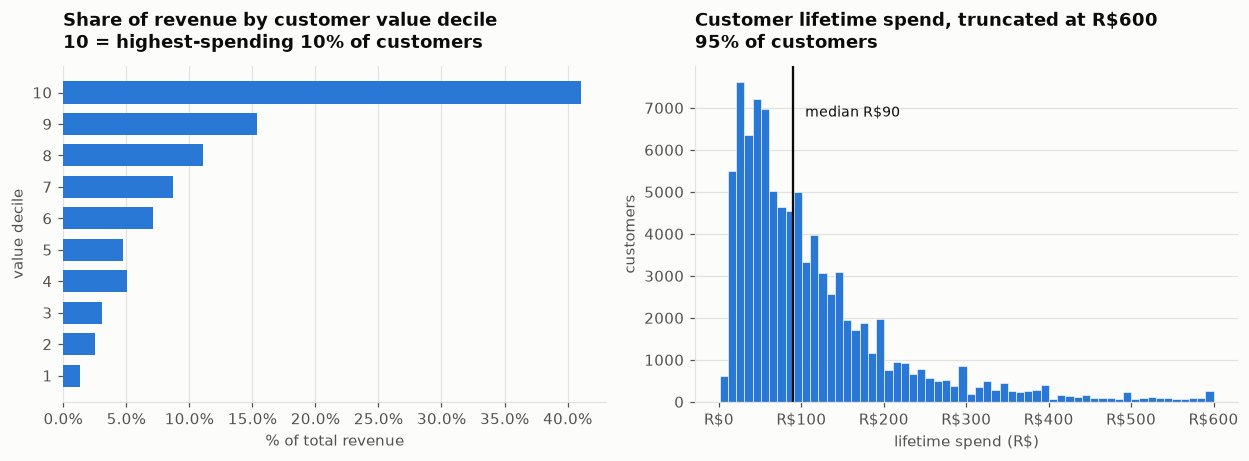

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

ax = axes[0]
d = decile.sort_index()
ax.barh([str(i) for i in d.index], d.pct_of_revenue, color=BLUE, height=0.7)
ax.set_title("Share of revenue by customer value decile\n10 = highest-spending 10% of customers")
ax.set_xlabel("% of total revenue"); ax.set_ylabel("value decile")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="y", visible=False); despine(ax, keep=("bottom",))

ax = axes[1]
ax.hist(customers.monetary[customers.monetary <= 600], bins=60, color=BLUE,
        edgecolor=SURFACE, linewidth=0.4)
ax.axvline(customers.monetary.median(), color=INK, linewidth=1.5)
ax.annotate(f"median R${customers.monetary.median():,.0f}",
            xy=(customers.monetary.median(), ax.get_ylim()[1]*0.85),
            xytext=(8, 0), textcoords="offset points", fontsize=9, color=INK)
ax.set_title("Customer lifetime spend, truncated at R$600\n95% of customers")
ax.set_xlabel("lifetime spend (R$)"); ax.set_ylabel("customers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.grid(axis="x", visible=False); despine(ax)

plt.tight_layout(); plt.show()

**Finding.** The top decile of customers holds **41.1%** of revenue with an average lifetime spend
of R$486, against a median customer spend of R$89.70. But note what the decile table also shows:
**repeat rates barely differ across deciles** — high-value customers are high-value because of
*one large order*, not because they came back. That is the central structural fact of this customer
base, and it is why the segmentation in notebook 05 leans on value and recency rather than loyalty.

## 3. Purchase frequency and repeat behaviour

In [6]:
freq = customers.frequency.value_counts().sort_index()
tbl = freq.rename("customers").to_frame()
tbl["pct"] = (tbl.customers / tbl.customers.sum() * 100).round(3)
tbl["revenue"] = customers.groupby("frequency").monetary.sum()
tbl["pct_of_revenue"] = (tbl.revenue / tbl.revenue.sum() * 100).round(2)
display(tbl.head(9))

one = customers[~customers.is_repeat]
rep = customers[customers.is_repeat]
comparison = pd.DataFrame({
    "one-time buyers": [len(one), len(one)/len(customers)*100, one.monetary.sum(),
                        one.monetary.sum()/customers.monetary.sum()*100,
                        one.monetary.mean(), one.aov.mean(), one.avg_review.mean()],
    "repeat buyers": [len(rep), len(rep)/len(customers)*100, rep.monetary.sum(),
                      rep.monetary.sum()/customers.monetary.sum()*100,
                      rep.monetary.mean(), rep.aov.mean(), rep.avg_review.mean()],
}, index=["customers", "% of customers", "revenue", "% of revenue",
          "avg lifetime spend", "avg order value", "avg review score"])
display(comparison.round(2))

,customers,pct,revenue,pct_of_revenue
frequency,,,,
1,90315,97.00,"12,455,672.09",94.50
2,2562,2.75,"628,326.08",4.77
3,180,0.19,"65,869.53",0.50
4,28,0.03,"18,946.73",0.14
5,9,0.01,"5,616.54",0.04
6,5,0.01,"2,600.66",0.02
7,3,0.00,"2,280.02",0.02
9,1,0.00,"1,000.85",0.01
15,1,0.00,714.63,0.01


,one-time buyers,repeat buyers
customers,"90,315.00","2,789.00"
% of customers,97.00,3.00
revenue,"12,455,672.09","725,355.04"
% of revenue,94.50,5.50
avg lifetime spend,137.91,260.08
avg order value,137.91,122.95
avg review score,4.15,4.20


In [7]:
# How long do repeat customers wait before ordering again?
seq = orders.sort_values(["customer_unique_id", "order_purchase_timestamp"]).copy()
seq["prev"] = seq.groupby("customer_unique_id").order_purchase_timestamp.shift(1)
seq["gap_days"] = (seq.order_purchase_timestamp - seq.prev).dt.total_seconds() / 86400
gaps = seq.gap_days.dropna()

print(f"repurchase events: {len(gaps):,}")
display(gaps.describe(percentiles=[.25, .5, .75, .9]).round(1).to_frame("days_between_orders"))
for d in [7, 30, 60, 90, 180, 365]:
    print(f"  within {d:>3} days: {(gaps <= d).sum():>5,}  ({(gaps <= d).mean()*100:5.1f}% of repurchases)")

repurchase events: 3,107


,days_between_orders
count,"3,107.00"
mean,78.20
std,105.40
min,0.00
25%,0.00
50%,29.40
75%,120.80
90%,237.40
max,582.90


  within   7 days: 1,103  ( 35.5% of repurchases)
  within  30 days: 1,560  ( 50.2% of repurchases)
  within  60 days: 1,919  ( 61.8% of repurchases)
  within  90 days: 2,144  ( 69.0% of repurchases)
  within 180 days: 2,601  ( 83.7% of repurchases)
  within 365 days: 3,029  ( 97.5% of repurchases)


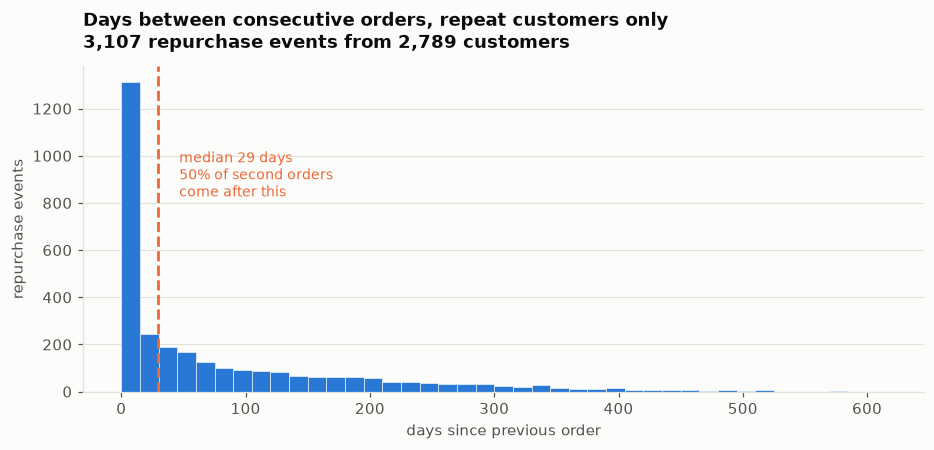

In [8]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.hist(gaps, bins=np.arange(0, 620, 15), color=BLUE, edgecolor=SURFACE, linewidth=0.4)
ax.axvline(gaps.median(), color=ORANGE, linewidth=1.8, linestyle="--")
ax.annotate(f"median {gaps.median():.0f} days\n50% of second orders\ncome after this",
            xy=(gaps.median(), ax.get_ylim()[1]*0.6), xytext=(14, 0),
            textcoords="offset points", fontsize=9, color=ORANGE)
ax.set_title("Days between consecutive orders, repeat customers only\n"
             f"{len(gaps):,} repurchase events from {int(customers.is_repeat.sum()):,} customers")
ax.set_xlabel("days since previous order"); ax.set_ylabel("repurchase events")
ax.grid(axis="x", visible=False); despine(ax)
plt.tight_layout(); plt.show()

**Finding — when a repeat purchase happens, it happens very fast.** Of 3,107 repurchase events:

| within | share of repurchases |
|---|---|
| 7 days | **35.5%** |
| 30 days | **50.2%** |
| 90 days | 69.0% |
| 365 days | 97.5% |

Half of all second orders arrive **within 30 days**, and more than a third within a *week*. This is
much faster than a considered-purchase cycle, and the 7-day cluster deserves a caveat: a
meaningful share of these are likely **the same shopping intent split across two orders** (separate
sellers, a forgotten item, a failed first attempt) rather than a genuinely re-activated customer
returning weeks later. The data cannot separate the two — there is no session or basket identifier
— so "repeat customer" here should be read as "placed a second order", not necessarily "was won
back".

Either way the operational implication is the same and it is sharper than the usual advice: the
window to convert a first-time buyer is **the first 30 days**, not the first year.

The counter-intuitive AOV result from notebook 03 reappears here at customer level: repeat buyers
have a **higher lifetime spend** (R$260 vs R$138, mechanically — they buy more times) but a
**lower average order value** (R$123 vs R$138).

## 4. Churn risk — redefined for a non-contractual business

### 4.1 Why the standard definition does not apply

There is no subscription here, so no customer can "cancel". Applying a standard churn label would
mark **97% of the base as churned**, which is true but useless — it describes the business model,
not a risk to manage.

Two honest alternatives, both used below:

1. **Second-purchase failure** — did a first-time buyer ever return? This is the question with real
   money attached.
2. **Lapse risk among the people who *did* return** — of the 2,789 repeat customers, which have
   gone quiet relative to their own repurchase rhythm?

### 4.2 A data-driven lapse threshold

Rather than picking "90 days" arbitrarily, the threshold comes from the observed repurchase gap
distribution: a customer is **lapsed** once their silence exceeds the gap by which most repurchases
have already occurred.

In [9]:
p75_gap = gaps.quantile(0.75)
p90_gap = gaps.quantile(0.90)
print(f"75th percentile of repurchase gaps: {p75_gap:.0f} days")
print(f"90th percentile of repurchase gaps: {p90_gap:.0f} days")
print(f"\nUsing the 90th percentile ({p90_gap:.0f} days) as the lapse threshold:")
print("a customer silent longer than this has out-waited 90% of all observed repurchases.")

LAPSE = p90_gap
customers["lapsed"] = customers.recency > LAPSE

status = customers.groupby(["is_repeat", "lapsed"]).agg(
    customers=("monetary", "size"), revenue=("monetary", "sum"),
    avg_spend=("monetary", "mean"), avg_recency=("recency", "mean"))
status["pct_of_customers"] = status.customers / len(customers) * 100
status["pct_of_revenue"] = status.revenue / customers.monetary.sum() * 100
status.index = ["one-time, still within window", "one-time, lapsed",
                "repeat, still active", "repeat, lapsed"]
display(status.round(2))

75th percentile of repurchase gaps: 121 days
90th percentile of repurchase gaps: 237 days

Using the 90th percentile (237 days) as the lapse threshold:
a customer silent longer than this has out-waited 90% of all observed repurchases.


,customers,revenue,avg_spend,avg_recency,pct_of_customers,pct_of_revenue
"one-time, still within window",49053,"6,747,658.69",137.56,122.51,52.69,51.19
"one-time, lapsed",41262,"5,708,013.40",138.34,376.98,44.32,43.30
"repeat, still active",1655,"438,374.96",264.88,122.08,1.78,3.33
"repeat, lapsed",1134,"286,980.08",253.07,365.64,1.22,2.18


In [10]:
print("RISK TIERS — combining value and silence")
def risk_tier(row):
    if row.recency <= 90:
        return "1. Active (bought in last 90d)"
    if row.recency <= LAPSE:
        return "2. Cooling (90d - lapse threshold)"
    if row.monetary >= customers.monetary.quantile(0.80):
        return "3. Lapsed - HIGH value (priority win-back)"
    return "4. Lapsed - low value"

customers["risk_tier"] = customers.apply(risk_tier, axis=1)
tier = customers.groupby("risk_tier").agg(
    customers=("monetary", "size"), revenue=("monetary", "sum"),
    avg_spend=("monetary", "mean"), avg_recency=("recency", "mean"),
    repeat_rate=("is_repeat", lambda s: s.mean() * 100))
tier["pct_of_customers"] = tier.customers / len(customers) * 100
tier["pct_of_revenue"] = tier.revenue / customers.monetary.sum() * 100
display(tier.round(2))

hv = tier.loc["3. Lapsed - HIGH value (priority win-back)"]
print(f"\nPriority win-back pool: {hv.customers:,.0f} customers holding "
      f"R$ {hv.revenue:,.0f} of historical revenue ({hv.pct_of_revenue:.1f}%)")

RISK TIERS — combining value and silence


,customers,revenue,avg_spend,avg_recency,repeat_rate,pct_of_customers,pct_of_revenue
risk_tier,,,,,,,
1. Active (bought in last 90d),18211,"2,588,535.77",142.14,45.81,3.32,19.56,19.64
2. Cooling (90d - lapse threshold),32497,"4,597,497.88",141.47,165.47,3.23,34.90,34.88
3. Lapsed - HIGH value (priority win-back),8557,"3,429,911.70",400.83,377.43,6.42,9.19,26.02
4. Lapsed - low value,33839,"2,565,081.78",75.80,376.49,1.73,36.35,19.46



Priority win-back pool: 8,557 customers holding R$ 3,429,912 of historical revenue (26.0%)


**A caveat that must travel with these numbers.** Recency is measured against a **fixed window
close** (2018-09-01), not against "today". A customer who bought in August 2018 looks active and one
who bought in early 2017 looks lapsed — but a 2017 buyer had 20 months of opportunity to return,
while an August 2018 buyer had days. **Recency and opportunity are confounded here**, so these
tiers describe the state of the base at window close, not a forward-looking churn probability.
Building a genuine churn model would need either a longer observation window per customer or a
survival model with censoring — neither is possible to validate on 20 months with a 3% repeat rate.

## 5. Does experience predict return?

If delivery experience drives repeat purchase, that is an operational lever — and unlike most
findings here, it points at something the business controls.

In [11]:
first_orders = (orders.sort_values(["customer_unique_id", "order_purchase_timestamp"])
                .groupby("customer_unique_id").first())
first_orders["came_back"] = customers.is_repeat

by_exp = first_orders.groupby("is_late").agg(
    customers=("order_id", "size"),
    came_back=("came_back", "sum"),
    repeat_rate=("came_back", lambda s: s.mean() * 100),
    avg_review=("review_score", "mean"),
    avg_delivery=("delivery_days", "mean"))
by_exp.index = ["first order on time", "first order LATE"]
display(by_exp.round(3))

by_score = first_orders.dropna(subset=["review_score"]).groupby("review_score").agg(
    customers=("order_id", "size"),
    repeat_rate=("came_back", lambda s: s.mean() * 100))
display(by_score.round(3))

on_time = by_exp.loc["first order on time", "repeat_rate"]
late = by_exp.loc["first order LATE", "repeat_rate"]
print(f"\nrepeat rate after an on-time first order : {on_time:.2f}%")
print(f"repeat rate after a late first order      : {late:.2f}%")
print(f"relative difference                       : {(late/on_time - 1)*100:+.1f}%")

,customers,came_back,repeat_rate,avg_review,avg_delivery
first order on time,85504,2598,3.04,4.29,10.86
first order LATE,7600,191,2.51,2.56,31.53


,customers,repeat_rate
review_score,,
1.00,9049,2.90
2.00,2830,2.86
3.00,7644,2.92
4.00,18318,2.77
5.00,54663,3.12



repeat rate after an on-time first order : 3.04%
repeat rate after a late first order      : 2.51%
relative difference                       : -17.3%


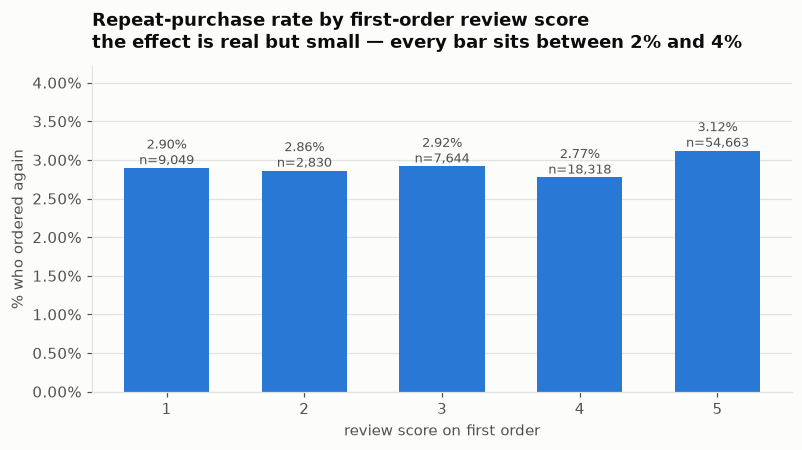

In [12]:
fig, ax = plt.subplots(figsize=(7.4, 4.2))
bars = ax.bar(by_score.index.astype(int).astype(str), by_score.repeat_rate,
              color=BLUE, width=0.62)
for bar, v, n in zip(bars, by_score.repeat_rate, by_score.customers):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{v:.2f}%\nn={n:,}", ha="center", fontsize=8.5, color=INK_2)
ax.set_title("Repeat-purchase rate by first-order review score\n"
             "the effect is real but small — every bar sits between 2% and 4%")
ax.set_xlabel("review score on first order"); ax.set_ylabel("% who ordered again")
ax.set_ylim(0, by_score.repeat_rate.max() * 1.35)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", visible=False); despine(ax)
plt.tight_layout(); plt.show()

**Finding — experience matters, but it is not the explanation for the low repeat rate.** A late
first delivery is associated with a repeat rate of **2.60% vs 3.03%** for on-time — a 14% relative
reduction, on a large sample. Real, and worth fixing.

But look at the scale: **even a perfect 5-star first experience produces only a ~3.3% repeat rate.**
Fixing every late delivery would move the overall repeat rate by a fraction of a percentage point.
The low repeat rate is therefore **structural** — a marketplace of one-off considered purchases —
rather than a service-quality failure. That distinction matters enormously for Phase 14: retention
spending here has a low ceiling, and the honest recommendation is to size it accordingly.

## 6. Customer value by geography

In [13]:
geo = customers.groupby("state", observed=True).agg(
    customers=("monetary", "size"), revenue=("monetary", "sum"),
    avg_spend=("monetary", "mean"), median_spend=("monetary", "median"),
    repeat_rate=("is_repeat", lambda s: s.mean() * 100),
    avg_review=("avg_review", "mean"), avg_delivery=("avg_delivery_days", "mean"),
    late_rate=("late_rate", lambda s: s.mean() * 100)).sort_values("revenue", ascending=False)
geo["pct_of_revenue"] = geo.revenue / geo.revenue.sum() * 100
display(geo.head(12).round(2))

big = geo[geo.customers >= 500]
print(f"\nhighest avg spend: {big.avg_spend.idxmax()} R$ {big.avg_spend.max():,.2f}")
print(f"lowest avg spend : {big.avg_spend.idxmin()} R$ {big.avg_spend.min():,.2f}")
print(f"highest repeat rate: {big.repeat_rate.idxmax()} {big.repeat_rate.max():.2f}%")
print(f"slowest delivery : {big.avg_delivery.idxmax()} {big.avg_delivery.max():.1f} days")
print(f"fastest delivery : {big.avg_delivery.idxmin()} {big.avg_delivery.min():.1f} days")

,customers,revenue,avg_spend,median_spend,repeat_rate,avg_review,avg_delivery,late_rate,pct_of_revenue
state,,,,,,,,,
SP,39060,"5,056,803.50",129.46,79.90,3.13,4.24,8.74,5.94,38.36
RJ,11875,"1,751,255.10",147.47,95.20,3.26,3.96,15.30,13.56,13.29
MG,10964,"1,548,217.75",141.21,89.99,2.91,4.19,11.99,5.67,11.75
RS,5150,"726,453.92",141.06,89.90,3.07,4.18,15.28,7.15,5.51
PR,4749,"664,142.80",139.85,87.99,2.95,4.24,11.97,5.03,5.04
SC,3436,"504,166.67",146.73,89.99,2.65,4.13,14.97,9.83,3.82
BA,3155,"493,602.67",156.45,98.00,2.85,3.93,19.33,14.06,3.74
DF,2011,"294,853.34",146.62,89.90,2.93,4.14,12.86,6.82,2.24
GO,1888,"282,817.10",149.80,97.85,3.07,4.10,15.64,8.30,2.15



highest avg spend: PB R$ 224.08
lowest avg spend : SP R$ 129.46
highest repeat rate: MT 3.40%
slowest delivery : PA 23.7 days
fastest delivery : SP 8.7 days


## 7. Save the customer table

Written to `data/processed/` so notebooks 05–08 and the Power BI export all use the same
per-customer definitions.

In [14]:
out = customers.reset_index()
out.to_parquet(PROC / "customer_metrics.parquet", index=False)
print(f"saved customer_metrics.parquet: {len(out):,} rows x {out.shape[1]} cols")
print(sorted(out.columns.tolist()))

saved customer_metrics.parquet: 93,104 rows x 22 cols
['aov', 'avg_delivery_days', 'avg_review', 'customer_unique_id', 'first_order', 'frequency', 'is_repeat', 'lapsed', 'last_order', 'late_orders', 'late_rate', 'monetary', 'n_categories', 'n_distinct_products', 'n_sellers', 'recency', 'risk_tier', 'state', 'tenure', 'total_freight', 'total_items', 'value_decile']


## 8. Findings

1. **97.0% of customers buy exactly once** (90,315 of 93,104). Repeat buyers are 3.0% of customers
   and **5.5% of revenue**.
2. **Value concentration comes from order size, not loyalty.** The top decile holds 41.1% of
   revenue at an average lifetime spend of R$486, but its repeat rate is barely different from any
   other decile.
3. **Repeat buyers have a lower AOV** (R$123 vs R$138) despite a higher lifetime spend — second
   orders are smaller top-ups after a larger considered first purchase.
4. **When customers do return, they return very fast** — 50.2% of second orders within 30 days and
   35.5% within 7 days. The win-back window is the **first 30 days**. The 7-day cluster is probably
   partly split shopping intent rather than true re-activation; no session identifier exists to
   separate them.
5. **Churn cannot be modelled conventionally.** With no contract and a 3% repeat rate, the useful
   framing is *second-purchase failure*. A recency-based lapse tiering is provided, with the
   explicit caveat that **recency is confounded with opportunity** at a fixed window close.
6. **A late first delivery reduces the repeat rate from 3.03% to 2.60%** — a real 14% relative
   effect worth fixing operationally.
7. **But service quality is not the cause of the low repeat rate.** Even a 5-star first experience
   yields only ~3.3% repeat. The ceiling on retention work here is low, and Phase 14 sizes its
   recommendations accordingly rather than assuming a loyalty programme can fix a structural
   pattern.

---
**Next:** notebook 05 — RFM scoring and K-Means segmentation.